# 1. Exploratory Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from chess_eval import *

## 1.0 Data Manager

We've collected all of the functions that have to do with the dataframe to uniformize its use and save on memory, especially helpful for the dataset of such sizes (see below).

You can see more details about the class in 'chess_eval/managers.py', but these are the main features:

- it is able to read a certain size of data and from that sample some rows (even using chunking to avoid test set leakage of similar positions) for the actual dataframe
- it automatically cleans the data: removes/clips positions with more/less than `EVAL_THRESHOLD` evaluation and converts the evaluation to a numeric value (see 1.1)
- it saves just one copy of all data, keeping only the indexes of the sampled, train and test sets (this way it doesn't store repeated data)
- it can apply feature transformers to the sampled dataset

It uses the default values for all values, so you can use the class out of the box just by initializing it with no arguments.

## 1.1 Dataset

To start, we can read the entire file (for now) and explore it.

In [2]:
dm = DataManager(
    read_size=None,
    cleaner=None,
)

Immediately, we see it is a big file, since it took so long to read.

In [3]:
display(dm.df_all.shape)
display(dm.df_all.columns)
dm.df_all.info(memory_usage="deep")

(12958035, 2)

Index(['FEN', 'Evaluation'], dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12958035 entries, 0 to 12958034
Data columns (total 2 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   FEN         object
 1   Evaluation  object
dtypes: object(2)
memory usage: 1.9 GB


We see it has around 13 million rows with only two columns, which are FEN (see 1.2) and Evaluation (see 1.3). In memory, it occupies a bit less than 2 GB! For practical reasons, we cannot train regressors on this king of datasize, so in practice we will sample a subset of these rows (the DataManager is already optimized to not store duplicate data).

One of the first things to do is to observer the type of the features: FEN is a string as expected, but it seems that Evaluation should be a numeric value.

In [4]:
try:
    eval_numeric = pd.to_numeric(dm.df_all[EVAL])
except ValueError as e:
    print(e)

Unable to parse string "#+6" at position 59


So we have values, which cannot be converted to integers.

In [5]:
eval_numeric = pd.to_numeric(dm.df_all[EVAL], errors="coerce")
dm.df_all[eval_numeric.isna()]

,FEN,Evaluation
59,7k/p1r2b2/4pq2/1p1p1nR1/5P2/P2B4/1P2Q2P/1K4R1 ...,#+6
60,7k/p1r2b2/4pq2/1p1p1BR1/5P2/P7/1P2Q2P/1K4R1 b ...,#+6
61,7k/p1r2b2/5q2/1p1p1pR1/5P2/P7/1P2Q2P/1K4R1 w -...,#+4
62,7k/p1r2b2/5q2/1p1p1p1R/5P2/P7/1P2Q2P/1K4R1 b -...,#+3
1440,7Q/8/4k3/p1p2p2/P7/1Pp1q1K1/6P1/8 w - - 3 64,#-19
...,...,...
12957453,5Q2/8/8/5K2/1p6/1k6/8/8 w - - 3 63,#+8
12957454,5Q2/8/8/8/1p2K3/1k6/8/8 b - - 4 63,#+9
12957551,1k5r/pb6/1p1R4/4p3/P1P3Q1/1q2B3/6PP/6K1 b - - ...,#-6
12957552,1k5r/pb6/1p1R4/4p3/P1P3Q1/4q3/6PP/6K1 w - - 0 36,#-5


We notice they all begin with a '#', and from __[this discussion](https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations/discussion/497472#2775858)__ we figure these represent forced __[checkmate](https://chess.fandom.com/wiki/Checkmate)__ followed by the number of moves.

In [6]:
sum(eval_numeric.isna()) / len(eval_numeric) * 100

1.4674601511726122

It represents less than 1.5% of the total dataset, which is very small considering we have more than enough rows either way. Because of that, we decide to just delete of all these cases.

In [7]:
dm.df_all = dm.df_all[~dm.df_all[EVAL].astype(str).str.contains("#")]
dm.df_all[EVAL] = pd.to_numeric(dm.df_all[EVAL]).astype(int)

Now we can check some basic statistics (more at 1.4):

In [8]:
dm.df_all[EVAL].describe()

count    1.276788e+07
mean     4.550662e+01
std      8.138864e+02
min     -1.531200e+04
25%     -7.100000e+01
50%      1.500000e+01
75%      1.440000e+02
max      1.531900e+04
Name: Evaluation, dtype: float64

## 1.2 FEN

Forsyth–Edwards Notation (FEN) is a standard notation for describing a particular board position of a chess game. The purpose of FEN is to provide all the necessary information to restart a game from a particular position. Note that it does not contain all the moves, only the current position of all pieces, plus some more additional information that is needed.

A FEN record contains six fields, each separated by a space. Take, for example game number 4444 (after data cleaning):

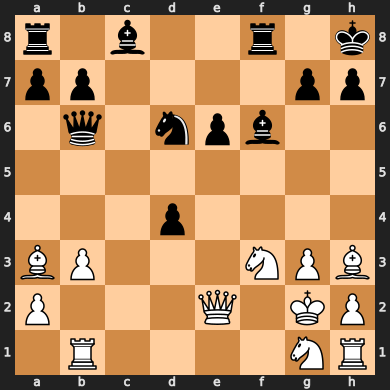

In [18]:
eg_fen = dm.df_all[FEN][4444]
chess.Board(eg_fen)

It's FEN is the following (separated into the 6 fields):

$$
\underbrace{ \text{r1b2r1k/pp4pp/1q1npb2/8/3p4/BP3NPB/P3Q1KP/1R4NR} }_{ A } \quad \underbrace{ \text{b} }_{ B } \quad \underbrace{ \text{-} }_{ C } \quad \underbrace{ \text{-} }_{ D } \quad \underbrace{ \text{3} }_{ E } \quad \underbrace{ \text{20} }_{ F }
$$

The fields are as follows:

- $A$: Piece placement
    - pawn = 'P', knight = 'N', bishop = 'B', rook = 'R', queen = 'Q' and king = 'K'
    - uppercase letters are white pieces, lowercase black pieces
    - digits from 1 to 8 indicate consecutive empty squares
    - for each rank (rank=row, 8 of them separated by "/") there are all the pieces described, starting from the a file (file=colum)
    - e.g.: starting from the top left we have: a black rook ('r'), an empty cell ('1'), a black bishop ('b'), two empty cells ('2'), etc.
- $B$: Active color:
    - 'w' for white to move, 'b' for black
    - e.g.: black to move
- $C$: [Castling](https://chess.fandom.com/wiki/Castling) availability
    - indicates which side (if any) can still castle (the right to castle can be lost once the king moves, something that you can't deduce from one single board position)
    - "K" for kingside castle, "Q" for queenside (lower case for black pieces), and "-" for none
    - e.g.: noone can castle
- $D$: [En passant](https://chess.fandom.com/wiki/En_passant) target square
    - squares (in algebraic notation) over which a pawn has just passed while moving two squares
    - "-" for no squares
    - e.g.: no en passant made
- $E$: Halfmove clock:
    - number of halfmoves since the last capture or pawn advance
    - used for the [fifty-move rule](https://chess.fandom.com/wiki/Fifty_move_rule)
    - e.g.: 3 halfmoves since the last capture or pawn advance
- $F$: Fullmove number:
    - number of the moves since the beginning of the game
    - e.g.: 20 moves


The idea is that this string contains all necessary information to know how this game can be continued, therefore also enabling us to know which side is doing better. In the following section we will discuss how we quantify the advantage of the two players.

## 1.3 Evaluation

An important theorem in the world of game theory is __[Zermelo's theorem](https://en.wikipedia.org/wiki/Zermelo%27s_theorem_(game_theory))__, which states

> In finite, deterministic, perfect-information, zero-sum games (like chess), from the starting position, either White can force a win, Black can force a win, or both can force at least a draw.

So that means that for all positions either one player has all the advantage (has a forced winning strategy), either the one, or none. The problem with chess is the exponential explosion of possibilities after each move, so we are not able to compute or decide which is the case for the game. The closest we can get to it are __[evaluations](https://www.chessprogramming.org/Evaluation)__. These are heuristic functions that try to predict the advantage of the players. The bigger the value, the more white pieces are winning; the smaller, the more black ones are; if zero, it means both sides are tied. The most common on is based on centipawns, which makes reference to the pawn's normalized value of 100 centipawns. From there, the bishop and knight are worth 300, the rook 500 and the queen 900.

One very basic interpretation of evaluation is the piece value difference, so if i have 800 more aggregated piece values than you, the evaluations will be around 800. In fact, this will be the starting point for our regressor, but more on that later.

Of course, apart from the material of the player, many other aspects have to be taken into account to accurately represent the advantages, such as the safety of the king, any potential attacking ideas, the development of the pieces, the pawn structure, etc.

 One important thing to notice about evaluations is that scale is not important nor significant (since it has more dimensions to it other than material). It is not really important if your position is +400 or +450 as long as your choosing moves that increase this evaluation or at least keep it steady. And also for practical applications, such as a simple minimax algorithm that can be implemented given an evaluation heuristic, it does not care about scale, only ordering of the evaluations (relative position to one another). More on this on the metric selection (see notebook 4_metric.ipynb).

## 1.4 Statistics

Let's now dive deeper into the numbers of our dataframe to understand it better.

In [21]:
eval_stats = dm.df_all["Evaluation"].describe()
eval_stats["std"] = dm.df_all["Evaluation"].std()
eval_stats["var"] = dm.df_all["Evaluation"].var()
eval_stats["skew"] = dm.df_all["Evaluation"].skew()
eval_stats

count    1.276788e+07
mean     4.550662e+01
std      8.138864e+02
min     -1.531200e+04
25%     -7.100000e+01
50%      1.500000e+01
75%      1.440000e+02
max      1.531900e+04
var      6.624111e+05
skew     3.315959e-01
Name: Evaluation, dtype: float64

We see it has a very big range of around 1.5k centipawns above and below zero. They are all centered around the mean of 45 (virtually drawn position, but slight advantatge for the white pieces, normal since they are the starting side) with a standard deviation of around 800. That means that approximately 68% of positions have an absolute evaluation of less than 800. The skew is pretty balanced, although there is a small bias towards white advantage.

Let's calculate the exact percentatges of the winning sides.

In [27]:
white = (dm.df_all[EVAL] > 0).sum()
black = (dm.df_all[EVAL] < 0).sum()
draws = (dm.df_all[EVAL] == 0).sum()

all = dm.df_all[EVAL].notna().sum()

percent_white = (white / all) * 100
percent_black = (black / all) * 100
percent_draws = (draws / all) * 100

print(f"White winning: {white} ({percent_white:5.2f}%)")
print(f"Black winning: {black} ({percent_black:5.2f}%)")
print(f"Draws        : {draws} ({percent_draws:5.2f}%)")

White winning: 6780727 (53.11%)
Black winning: 4725798 (37.01%)
Draws        : 1261356 ( 9.88%)


We can check the percentage of data in some example interval, say $[-1000, 1000]$.

In [29]:
((dm.df_all[EVAL] >= -1000) & (dm.df_all[EVAL] <= 1000)).mean() * 100

np.float64(95.42050086463055)

We can plot the evaluation distribution histogram to better analyze the distribution.

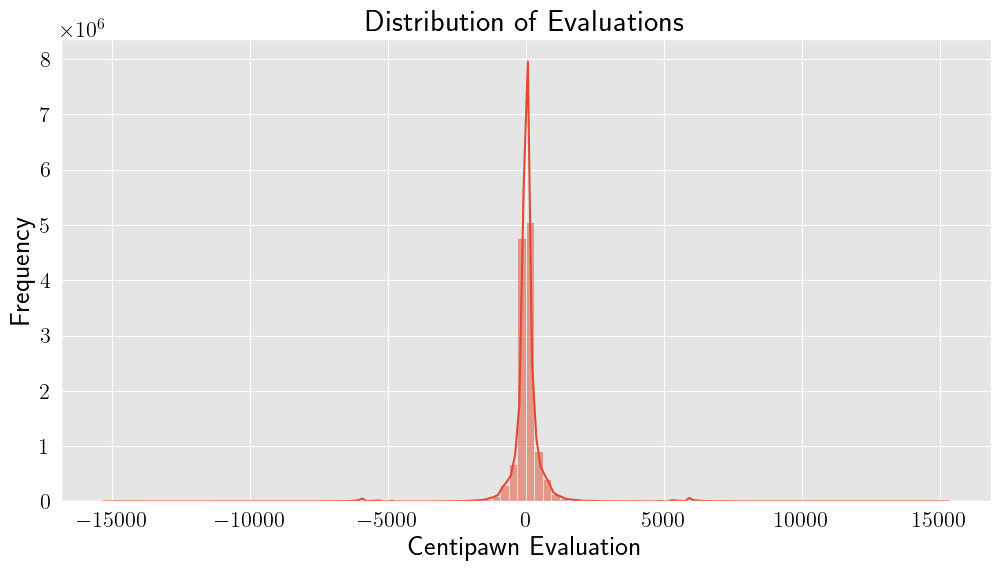

In [30]:
sns.histplot(dm.df_all[EVAL], bins=100, kde=True)
plt.title("Distribution of Evaluations")
plt.xlabel("Centipawn Evaluation")
plt.ylabel("Frequency")
plt.show()

We (basically) have outlier at extreme values that mess up with the distribution. Let's analyze the boxplot to better visualize these 'outlier' values.

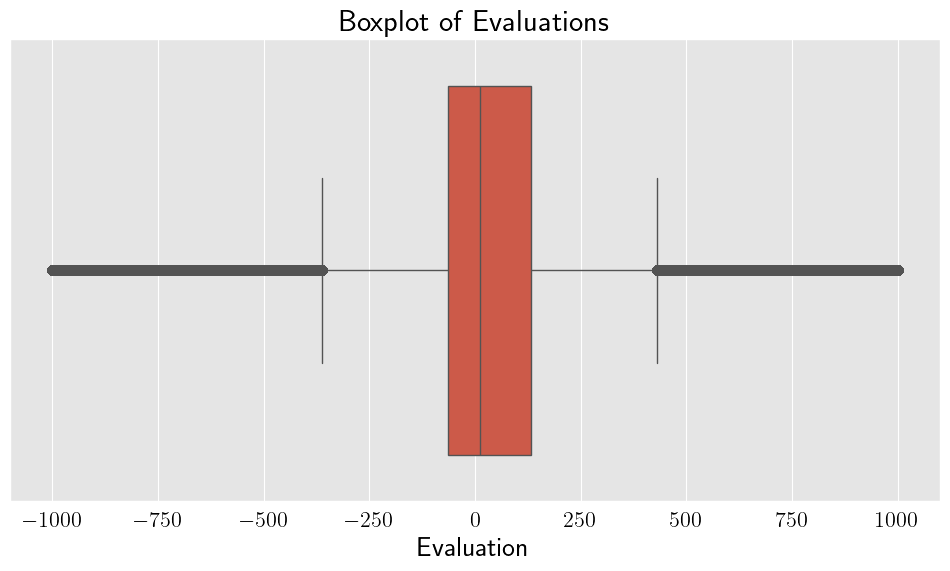

In [33]:
sns.boxplot(x=dm.df_all[EVAL])
plt.title("Boxplot of Evaluations")
plt.show()

We saw earlier that positions with an evaluation bigger than 1000 represent less than 5% of the whole dataset, which we confirm with this plot: most of the games are around the $\pm 100$ centipawns. We think that these extrem values can affect the way the models interpret these data points, so we decide to cut off any sample that exceeds this threashdold.

The justification is that for enormous evaluations it means that there is a checkmate somewhere around the corner but the engine hasn't been able to find it yet.

In [34]:
dm.df_all = dm.df_all[dm.df_all[EVAL].abs() <= EVAL_THRESHOLD]
dm.sample()

,FEN,Evaluation
0,1rbqk2r/3n1p1n/p5pb/2pPp2p/1pP2P2/3BB3/PP1QNN2...,144
1,8/4r1kp/7r/p2R1p2/1b2pP1P/1B4P1/P3K3/2R5 b - -...,13
2,r1bqrbk1/p2n1ppp/2p2n2/1pPpp3/3P4/1P3NP1/P1QNP...,58
3,4b1q1/4k2p/1p1p1p2/p1pPpPr1/PnP1P3/1P3BPR/3Q4/...,0
4,2n2rk1/5pbp/3Q2p1/2p2q2/1P6/P3P1P1/1R3P2/2B2NK...,-80
...,...,...
995,r5k1/2nnB1pp/1q2p3/2ppP3/8/2N3Q1/PP3PPP/R4bK1 ...,30
996,3R4/2p2pkp/5rp1/8/2B5/1P4bP/4K3/8 b - - 6 37,-246
997,r1bq1rk1/1pp3pp/2nbp3/3p1p2/p1PP1B1P/P1n1PNP1/...,61
998,1k4rr/ppp3q1/2n1Qp1p/2p1p3/7N/3P3P/PPP2PP1/R3R...,-429


We can plot again the distribution.

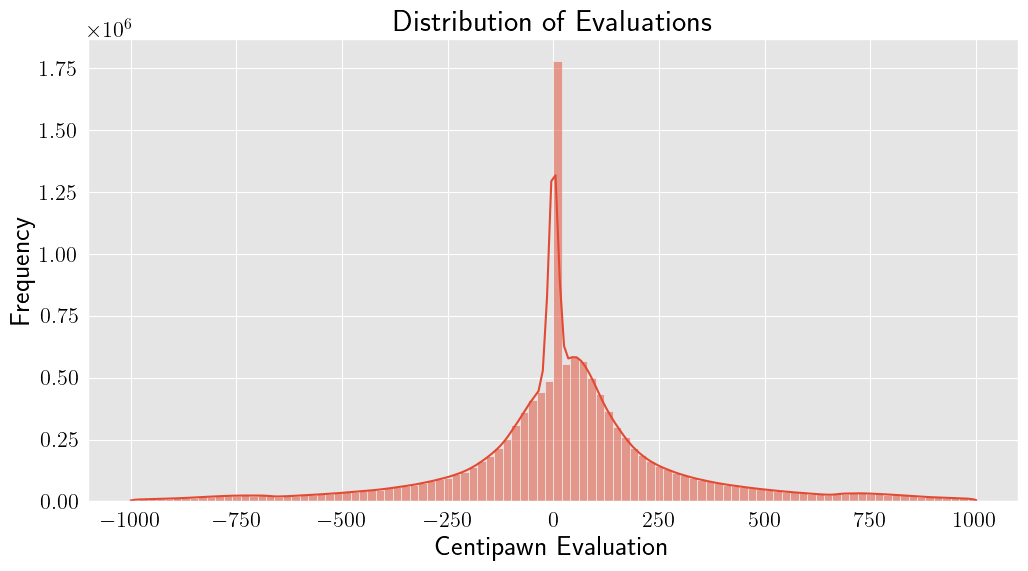

In [35]:
sns.histplot(dm.df_all[EVAL], bins=100, kde=True)
plt.title("Distribution of Evaluations")
plt.xlabel("Centipawn Evaluation")
plt.ylabel("Frequency")
plt.show()

We are now getting closer to a normal distribution, although we have a big spike right above the zero. We could try to normalize it further, but in reality most games are either way going to be around that area, so we'll leave it as it.

## 1.5 Consecutive Games

Let's have a look at a random position and its adjacent rows.

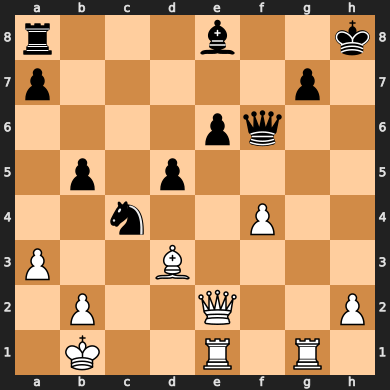

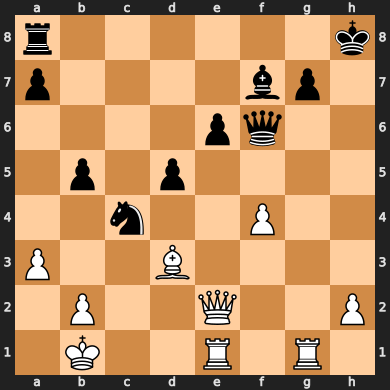

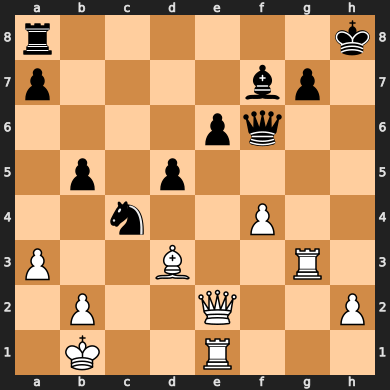

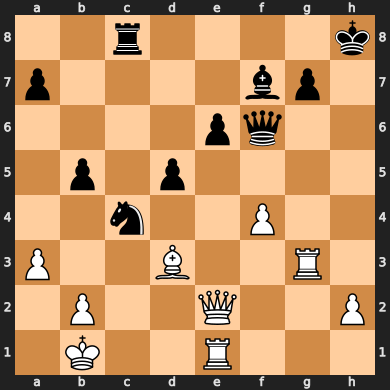

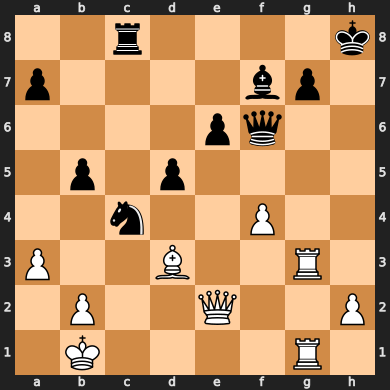

In [37]:
display(chess.Board(dm.df_all[FEN][EXAMPLE_GAME_ID]))
display(chess.Board(dm.df_all[FEN][EXAMPLE_GAME_ID + 1]))
display(chess.Board(dm.df_all[FEN][EXAMPLE_GAME_ID + 2]))
display(chess.Board(dm.df_all[FEN][EXAMPLE_GAME_ID + 3]))
display(chess.Board(dm.df_all[FEN][EXAMPLE_GAME_ID + 4]))

These are all part of the same game, so they're basically the same up to some piece movement. This represents a challenge for out train and test split, since sending one these consecutive games to training and one to testing basically consists of data leakage. Let's look at the evaluation over the position index.

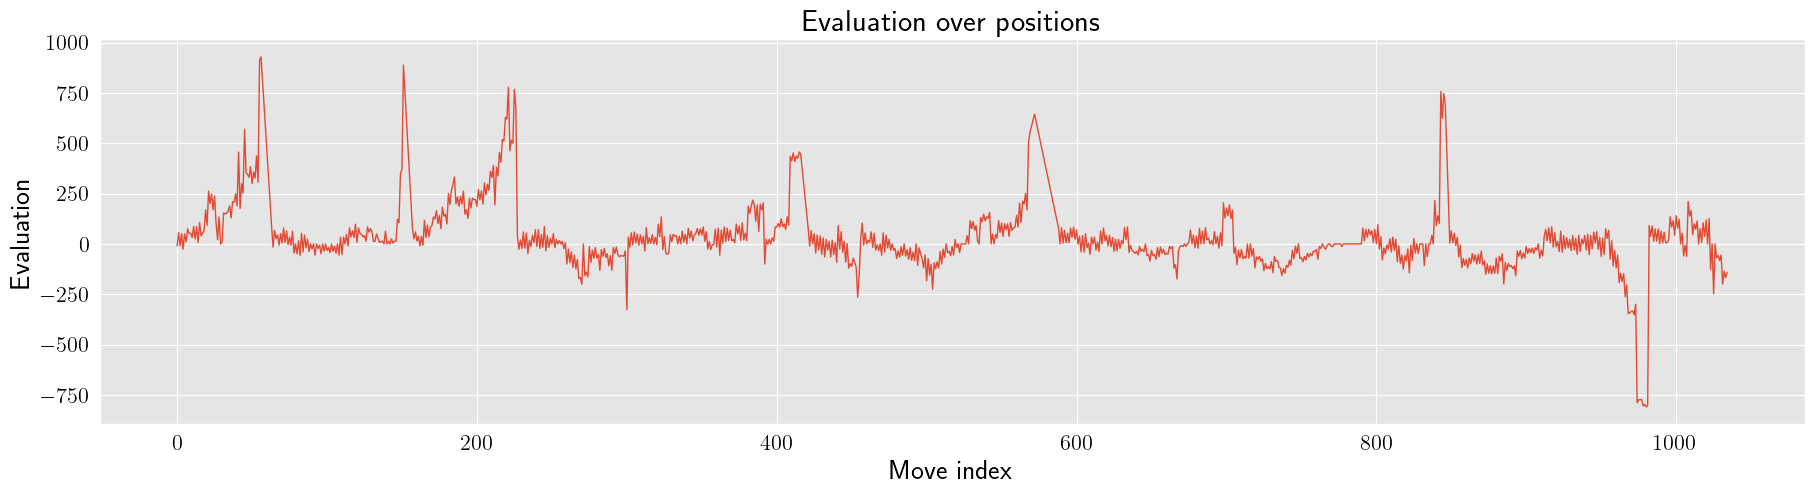

In [45]:
subset = dm.df_all[EVAL].iloc[:1000]
plt.figure(figsize=(22,5))
plt.plot(subset.index, subset.values, markersize=2, linewidth=1)
plt.xlabel("Move index")
plt.ylabel("Evaluation")
plt.title("Evaluation over positions")
plt.show()

We could see a pattern here: starting from an initial drawn position, a series of movements are made that tend in the same winning position of one player, which then ends with a big spike (and maybe a following forced checkmate), and then jumping back down to an initial almost-drawn position.

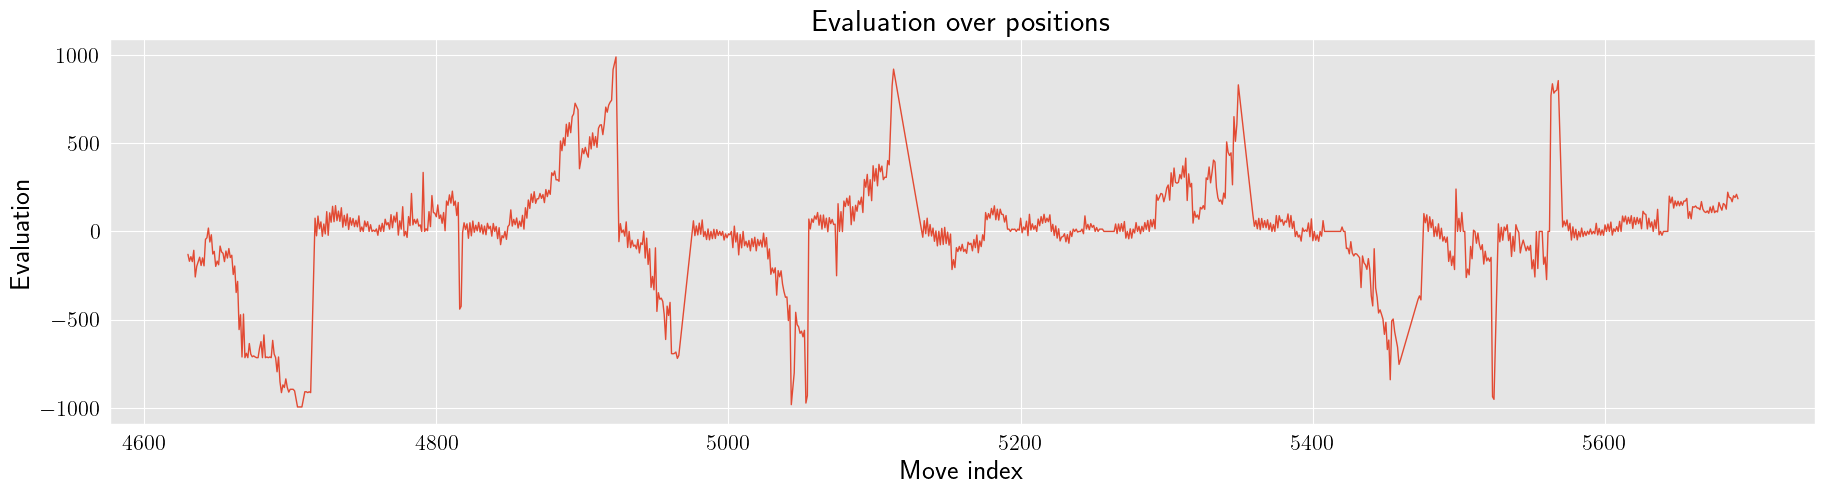

In [46]:
subset = dm.df_all[EVAL].iloc[4444:4444+1000]
plt.figure(figsize=(22,5))
plt.plot(subset.index, subset.values, markersize=2, linewidth=1)
plt.xlabel("Move index")
plt.ylabel("Evaluation")
plt.title("Evaluation over positions")
plt.show()

And this pattern repeats throughout the dataset, with an approximate period of 100 positions per game. We can use this to efficiently sample game by chuncks, which we will discuss in the following section.

## 1.6 Chunked sampling

In [47]:
# TODO